In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(eps * mu)

# --- domínio ---
min_lambda = vp / 1e9  # comprimento de onda mínimo para 1 GHz = 3e-1 m
Nx = Ny = 50
dx = dy = 0.1 * min_lambda
dt = dx / (vp * np.sqrt(2))
Nt = 100
L = Nx * dx
T = Nt * dt

cx, cy = Nx // 2, Ny // 2

grid_x_Ez = np.linspace(0, L, Nx + 1)
grid_y_Ez = np.linspace(0, L, Ny + 1)
grid_t_Ez = np.linspace(0, T, Nt + 1)

grid_x_Hx = np.linspace(0, L, Nx + 1)
grid_y_Hx = np.linspace(dy/2, L - dy/2, Ny)
grid_t_Hx = np.linspace(dt/2, T - dt/2, Nt)

grid_x_Hy = np.linspace(dx/2, L - dx/2, Nx)
grid_y_Hy = np.linspace(0, L, Ny + 1)
grid_t_Hy = np.linspace(dt/2, T - dt/2, Nt)

# --- campos ---
Ez_curr = Ez_next = np.zeros((grid_x_Ez.shape[0], grid_y_Ez.shape[0]))
Hx_curr = Hx_next = np.zeros((grid_x_Hx.shape[0], grid_y_Hx.shape[0]))
Hy_curr = Hy_next = np.zeros((grid_x_Hy.shape[0], grid_y_Hy.shape[0]))

# ponta de prova para coletar pontos para a FFT no centro da cavidade
probe = []

# valores do tempo para salvar os snapshots e montar os heatmaps
n_snapshots = np.linspace(20, Nt - 5, 6, dtype=int)
Ez_snapshots = []

for n in range(Nt-1):
    # --- fonte (pulso gaussiano no tempo) ---
    source_gaussiano = np.exp(-((n * dt - 1.8e-9)**2) / (0.6e-9)**2)

    # --- fonte (senoidal no tempo) ---
    frequency = 30e9
    source_senoidal = np.sin(2 * np.pi * frequency * n * dt)

    Ez_curr[cx, cy] += source_senoidal

    Hx_next[:, :] = Hx_curr[:, :] - (dt/(mu*dy)) * (
        Ez_curr[:, 1:] - Ez_curr[:, :-1]
    )

    Hy_next[:, :] = Hy_curr[:, :] + (dt/(mu*dx)) * (
        Ez_curr[1:, :] - Ez_curr[:-1, :]
    )

    Ez_next[1:-1, 1:-1] = Ez_curr[1:-1, 1:-1] + (dt/eps) * (
        (Hy_next[1:, 1:-1] - Hy_next[:-1, 1:-1]) / dx -
        (Hx_next[1:-1, 1:] - Hx_next[1:-1, :-1]) / dy
    )

    # zero nas nas extremidades - PEC
    Ez_next[:, 0] = 0
    Ez_next[:, -1] = 0
    Ez_next[0, :] = 0
    Ez_next[-1, :] = 0

    # salva o valor no centro para a FFT
    probe.append(Ez_next[cx + 25, cy + 25])

    # atualiza os campos para o próximo passo
    Ez_curr = Ez_next.copy()
    Hx_curr = Hx_next.copy()
    Hy_curr = Hy_next.copy()

    # salva para os snapshots
    if n in n_snapshots:
        Ez_snapshots.append(Ez_curr.copy())


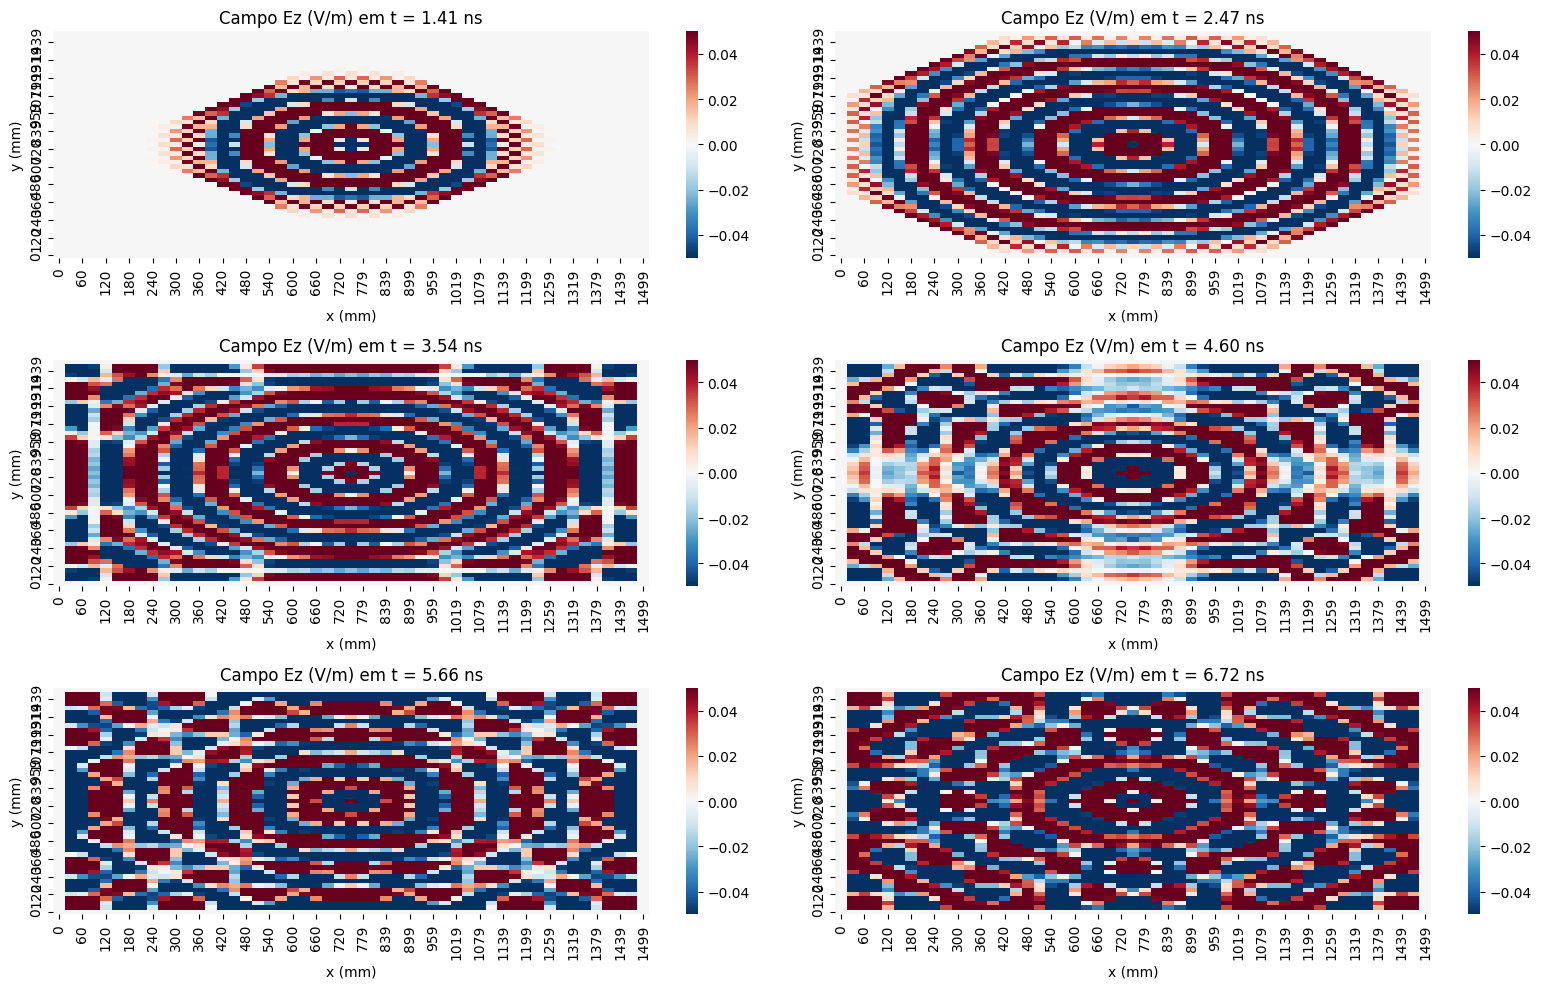

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    sns.heatmap(Ez_snapshots[i], ax=ax, annot=False, cmap='RdBu_r',vmin=-0.05, vmax=0.05,center=0)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title(f"Campo Ez (V/m) em t = {n_snapshots[i]*dt*1e9:.2f} ns")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 1000:.0f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 1000:.0f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [5]:
# Create the plot
idx_range_to_plot = range(75, 150)
idx_range_to_plot = range(0, Nx)
xgrid = np.linspace(0, Nx * dx, Nx)
r = xgrid - xgrid[Nx//2]

plt.plot(xgrid[idx_range_to_plot],  Ez[Nt - 10, idx_range_to_plot, Ny // 2], label='Ex (V/m)')
# plt.plot(xgrid, Ez[Nt - 10, Nx//2, Ny // 2] / np.sqrt(np.abs(r)), label='Decaimento')

# Add labels and title
plt.xlabel('x (m)')
plt.ylabel('Ez (V/m)')
plt.legend()

# Display the plot
plt.show()

NameError: name 'Ez' is not defined

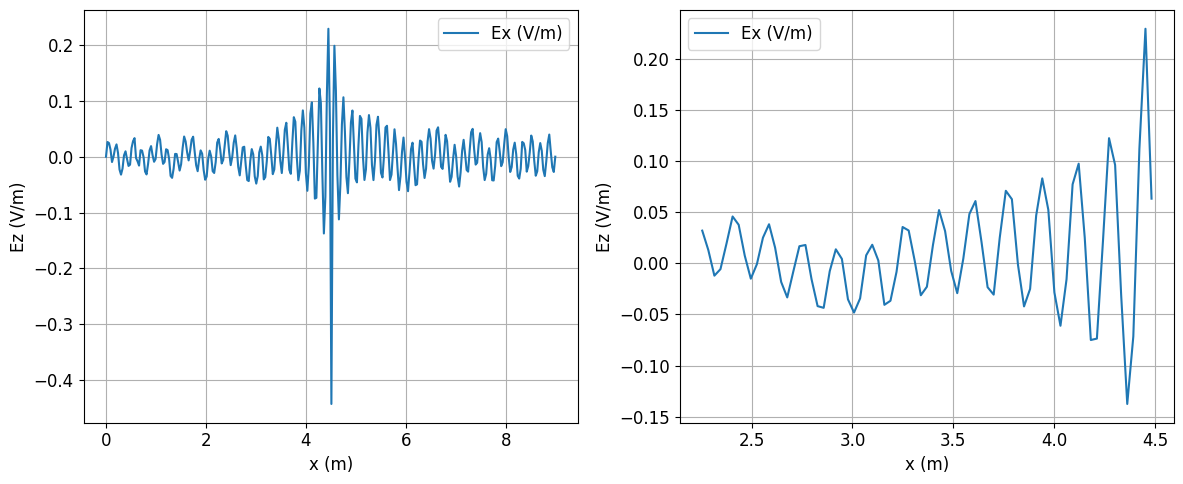

In [ ]:
plt.rcParams.update({'font.size': 12}) 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

idx_range_to_plot = range(75, 150)
idx_range_to_plot = range(0, Nx)
xgrid = np.linspace(0, Nx * dx, Nx)
r = xgrid - xgrid[Nx//2]


axes[0].plot(xgrid[idx_range_to_plot],  Ez[Nt - 10, idx_range_to_plot, Ny // 2], label='Ex (V/m)')
axes[0].set_xlabel('x (m)')
axes[0].set_ylabel('Ez (V/m)')
axes[0].grid()
axes[0].legend()

axes[1].plot(xgrid[range(75, 150)],  Ez[Nt - 10, range(75, 150), Ny // 2], label='Ex (V/m)')
axes[1].set_xlabel('x (m)')
axes[1].set_ylabel('Ez (V/m)')
axes[1].grid()
axes[1].legend()

plt.tight_layout()
plt.show()